<a href="https://colab.research.google.com/github/mahim83/Deep-Learning-Assignments-certificates/blob/main/Assignment3_multiple_linear_regression_using_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/multiple_linear_regression_dataset (1).csv')

# Display the first few rows of the DataFrame
df.head()

,age,experience,income
0,25,1,30450
1,30,3,35670
2,47,2,31580
3,32,5,40130
4,43,10,47830


In [2]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Separate features (X) and target (y)
X = df.drop('income', axis=1)
y = df['income']

# 2 & 3. Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4 & 5. Add a bias term to the scaled features
bias_term = np.ones((X_scaled.shape[0], 1))
X = np.hstack((bias_term, X_scaled))

print("Features (X) shape after adding bias and scaling:", X.shape)
print("Target (y) shape:", y.shape)
print("First 5 rows of X (with bias term and scaled features):\n", X[:5])
print("First 5 rows of y:\n", y[:5])

Features (X) shape after adding bias and scaling: (20, 3)
Target (y) shape: (20,)
First 5 rows of X (with bias term and scaled features):
 [[ 1.         -1.49890262 -1.29354835]
 [ 1.         -0.98733176 -0.79602975]
 [ 1.          0.75200916 -1.04478905]
 [ 1.         -0.78270342 -0.29851116]
 [ 1.          0.34275248  0.94528533]]
First 5 rows of y:
 0    30450
1    35670
2    31580
3    40130
4    47830
Name: income, dtype: int64


In [3]:
import numpy as np

# 1. Initialize weights
# The number of weights should be equal to the number of features in X (including the bias term).
X_shape = X.shape[1] # X has shape (n_samples, n_features_with_bias)
weights = np.zeros(X_shape) # Initialize weights to zeros

# Or, alternatively, initialize with small random values:
# weights = np.random.rand(X_shape)

print(f"Initial weights: {weights}")
print(f"Number of weights: {len(weights)}")

# 2. Define the prediction function
def predict(X_row, weights):
    """Calculates the predicted output for a single feature vector."""
    return np.dot(X_row, weights)

# 3. Define the weight update function
def update_weights(X_row, y_true, y_pred, weights, learning_rate):
    """Updates the weights based on the prediction error."""
    error = y_true - y_pred
    # Perceptron weight update rule for regression (similar to gradient descent for MSE)
    weights = weights + learning_rate * error * X_row
    return weights

print("Perceptron prediction and weight update functions defined.")

Initial weights: [0. 0. 0.]
Number of weights: 3
Perceptron prediction and weight update functions defined.


In [4]:
import numpy as np

# Define learning parameters
learning_rate = 0.01
epochs = 100

# Get the number of features (including bias)
n_features = X.shape[1]

# Initialize weights if they haven't been initialized, though they should be from the previous step
# If starting fresh, uncomment: weights = np.zeros(n_features)

print(f"Initial weights before training: {weights}")

# Training loop
for epoch in range(epochs):
    for i in range(X.shape[0]): # Iterate over each data point
        X_row = X[i]
        y_true = y.iloc[i] # Use .iloc for Series to get the scalar value

        # Predict output for the current row
        y_pred = predict(X_row, weights)

        # Update weights
        weights = update_weights(X_row, y_true, y_pred, weights, learning_rate)

print(f"Weights after {epochs} epochs of training: {weights}")
print("Perceptron training complete.")

Initial weights before training: [0. 0. 0.]
Weights after 100 epochs of training: [40708.23966901  -962.13502156  8705.20959631]
Perceptron training complete.


In [5]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Make predictions on the entire dataset using the trained weights
predictions = []
for i in range(X.shape[0]):
    y_pred_single = predict(X[i], weights)
    predictions.append(y_pred_single)

# Convert predictions list to a NumPy array
predictions = np.array(predictions)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y, predictions)

print(f"Perceptron Model MSE: {mse}")


Perceptron Model MSE: 1534699.7616248264


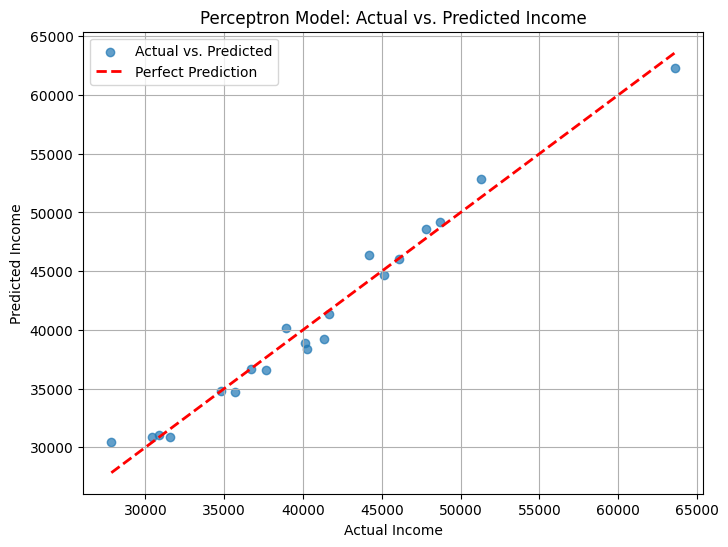

In [6]:
import matplotlib.pyplot as plt

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y, predictions, alpha=0.7, label='Actual vs. Predicted')

# Add a line representing perfect predictions (actual == predicted)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

# Label axes and add title
plt.xlabel('Actual Income')
plt.ylabel('Predicted Income')
plt.title('Perceptron Model: Actual vs. Predicted Income')

# Add a legend
plt.legend()

# Display the plot
plt.grid(True)
plt.show()
